In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
%load_ext autoreload
%autoreload 2

In [3]:
from masato.utils import read_table
from masato.get_abundance import get_otu_count
from masato.plot_dm import plot_dm
from masato.plot import get_abundance_plot, get_alpha_diversity_plot

In [4]:
plt.rcParams['font.family'] = 'Arial'
plt.rcParams["pdf.fonttype"] = 42
plt.rcParams['svg.fonttype'] = 'none'

In [5]:
zotu_count_path = "./output_unoise3_16s/unoise3_zotu.biom"
metadata_path = "./metadata/batch_1_2.tsv"
taxonomy_path = "./output_unoise3_16s/unoise3_zotu_rrndb_processed.tsv"

In [6]:
otu_count, otu_metadata, otu_taxonomy = get_otu_count(
    otu_count_table=zotu_count_path,
    metadata_path=metadata_path,
    otu_taxonomy_path=taxonomy_path,
    sample_weight_key="sample_weight",
    spikein_taxa_key="spike_in",
)

# ===== QC =====
# drop samples with total counts < thres
sample_min_asvs = 2
samples_good = (otu_count > 0).sum(axis=1) >= sample_min_asvs
print(f"Dropping {otu_count.shape[0] - samples_good.sum()} samples with < {sample_min_asvs} ASVs.")
otu_count = otu_count.loc[samples_good]
otu_metadata = otu_metadata.loc[samples_good]
# drop taxa that appear in less than thres samples, and also drop 16S-U_UNKNOWN
# asv_min_samples = 2
# taxa_good = ((otu_count > 0).sum(axis=0) >= asv_min_samples) & (otu_taxonomy.index != "16S-U_UNKNOWN")
# print(f"Dropping {otu_count.shape[1] - taxa_good.sum()} taxa that appear in < {asv_min_samples} samples.")
# otu_taxonomy = otu_taxonomy.loc[taxa_good]
# otu_count = otu_count.loc[:, taxa_good]


Dropping 2 samples with < 2 ASVs.


In [7]:
samples_good

YSEBYY20220916P1wA4     True
EB-Batch2-1d            True
YSEBYY20220916P1wB4     True
YSEBYY20220916P1wC4     True
YSEBYY20220916P1wD4     True
YSEBYY20220916P1wA5     True
YSEBYY20220916P1wG5     True
YSEBYY20220916P1wH5     True
EB-Batch2-2l            True
20230728YSEB2wA2        True
20230728YSEB2wB2        True
EB-Batch2-2o            True
YSEBYY20220916P1wE4     True
YSEBYY20220916P1wF4     True
20230728YSEB2wA1        True
20230728YSEB2wB1        True
20230728YSEB2wC1        True
20230728YSEB2wD1        True
EB-Batch2-3i            True
YSEBYY20220916P1wG4    False
YSEBYY20220916P1wH4     True
EB-Batch2-4c            True
YSEBYY20220916P1wB5     True
YSEBYY20220916P1wC5     True
YSEBYY20220916P1wD5     True
YSEBYY20220916P1wE5     True
YSEBYY20220916P1wF5     True
EB-Batch2-8b            True
20230728YSEB2wE1        True
20230728YSEB2wF1        True
EB-Batch2-10b           True
20230728YSEB2wG1        True
20230728YSEB2wH1        True
20230728YSEB2wC2        True
EB-Batch2-12b 

In [8]:
def rename_sample(name: str) -> str:
    if name == "SUB2h1":
        name = "SUB2k"
    elif name == "SUB2h2":
        name = "SUB2h"
    elif name == "SUB7a1":
        name = "SUB7a"
    elif name == "SUB7a2":
        name = "SUB6a"
    elif name == "SUB18a1":
        name = "SUB18a"
    elif name == "SUB18a2":
        name = "SUB19a"
    
    name = name.replace("SUB", "")
    # append 0 if name is a single digit
    name = name.zfill(3).upper()
    return name


In [9]:
otu_metadata["_rep_group"] = otu_metadata["rep_group"].copy()
otu_metadata["rep_group"] = otu_metadata["_rep_group"].map(
    lambda x: rename_sample("SUB" + x.split(":")[0].lower())
)
otu_metadata.head(20)

,rep_group,sample_group,reference,spike_in,sample_weight,batch,Date of Culture,location,result,location_short,spikein_reads,non_spikein_reads,norm_factor,sequencing_depth,_rep_group
sample,,,,,,,,,,,,,,,
YSEBYY20220916P1wA4,01A,EB batch 1 & 2,NaN,NaN,NaN,1,2021-12-02,Ankle (L),MSSA,Ankle,-1.0,3083.0,NaN,3083.0,01a: Ankle (L) - MSSA
EB-Batch2-1d,01D,EB batch 1 & 2,NaN,NaN,NaN,2,2024-02-01,Arm (R),MSSA,Arm,-1.0,1080.0,NaN,1080.0,01d: Arm (R) - MSSA
YSEBYY20220916P1wB4,02A,EB batch 1 & 2,NaN,NaN,NaN,1,2021-12-16,Foot (L),P. aeruginosa,Foot,-1.0,10624.0,NaN,10624.0,02a: Foot (L) - P. aeruginosa
YSEBYY20220916P1wC4,02B,EB batch 1 & 2,NaN,NaN,NaN,1,2021-12-16,Buttock (L),P. aeruginosa,Buttock,-1.0,1496.0,NaN,1496.0,02b: Buttock (L) - P. aeruginosa
YSEBYY20220916P1wD4,02C,EB batch 1 & 2,NaN,NaN,NaN,1,2021-12-16,Shin (L),S. marcescens,Shin,-1.0,193679.0,NaN,193679.0,02c: Shin (L) - S. marcescens
YSEBYY20220916P1wA5,02H,EB batch 1 & 2,NaN,NaN,NaN,1,2022-03-17,Forearm (L),MSSA,Forearm,-1.0,970.0,NaN,970.0,02h: Forearm (L) - MSSA
YSEBYY20220916P1wG5,02I,EB batch 1 & 2,NaN,NaN,NaN,1,2022-06-09,Foot (L),K. oxytoca,Foot,-1.0,17001.0,NaN,17001.0,02i: Foot (L) - K. oxytoca
YSEBYY20220916P1wH5,02J,EB batch 1 & 2,NaN,NaN,NaN,1,2022-06-09,Thigh (L),E. coli; A. baumannii c.,Thigh,-1.0,21850.0,NaN,21850.0,02j: Thigh (L) - E. coli; A. baumannii c.
EB-Batch2-2l,02L,EB batch 1 & 2,NaN,NaN,NaN,2,2022-11-17,Thigh (L),A. baumannii c.; MSSA,Thigh,-1.0,115654.0,NaN,115654.0,02l: Thigh (L) - A. baumannii c.; MSSA


In [10]:
otu_count

#OTU_ID,16S-U1,16S-U2,16S-U3,16S-U4,16S-U5,16S-U6,16S-U7,16S-U8,16S-U9,16S-U10,...,16S-U80,16S-U81,16S-U82,16S-U83,16S-U84,16S-U85,16S-U86,16S-U87,16S-U88,16S-U_UNKNOWN
YSEBYY20220916P1wA4,3068,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,15
EB-Batch2-1d,986,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,42
YSEBYY20220916P1wB4,0,610,3803,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,37
YSEBYY20220916P1wC4,11,17,515,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,9
YSEBYY20220916P1wD4,895,130298,170,0,0,0,0,0,0,17143,...,0,0,0,0,0,0,0,0,0,762
YSEBYY20220916P1wA5,735,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,34
YSEBYY20220916P1wG5,0,60,82,0,3989,0,0,0,0,90,...,0,0,0,0,0,0,15,0,12,69
YSEBYY20220916P1wH5,6703,110,108,9733,730,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,83
EB-Batch2-2l,18,0,2898,71500,0,37386,0,0,0,0,...,0,0,0,0,16,16,0,0,0,194
20230728YSEB2wA2,327,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,40


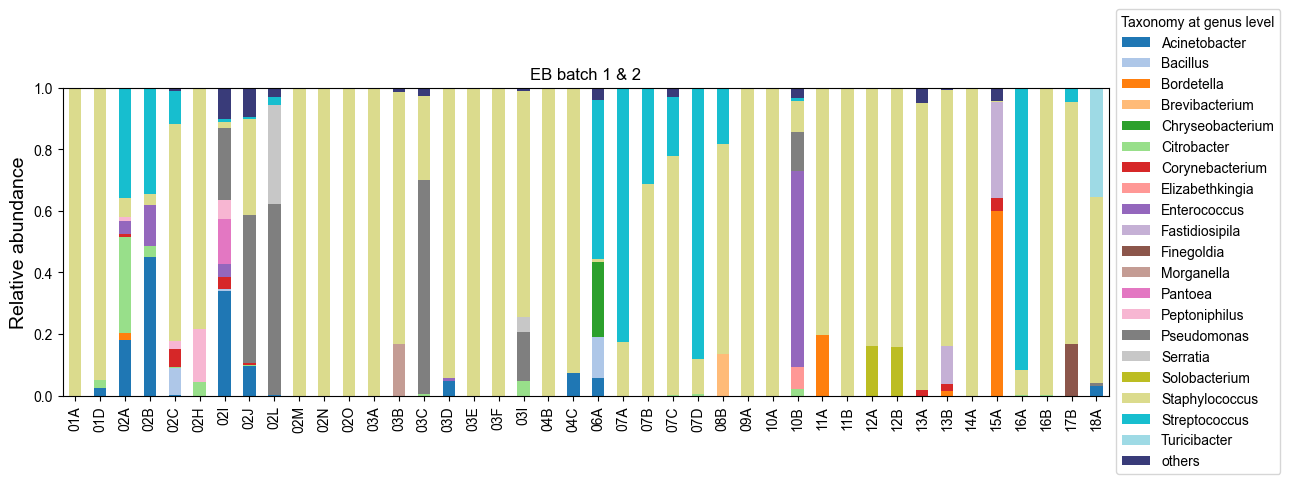

In [11]:
taxa = ["genus"]
rel_ab_thresholds = [0.05]
figs = get_abundance_plot(
    otu_count,
    otu_metadata,
    otu_taxonomy,
    rep_group_key="rep_group",
    sample_group_key="sample_group",
    tax_levels=taxa,
    rel_ab_thresholds=rel_ab_thresholds,
    plot_type="stacked_bar",
    feature_ordering=None,
    #
    orientation="vertical",
    isolate_rep_group_key=None,
    isolate_sample_group_key=None,
    sample_hierarchical_clustering=False,
    keep_rare=True,
    keep_unknown=False,
    # cmap="summer",
)
for tax, fig in zip(taxa, figs):
    fig.savefig(f"./figs/rel_ab_sb_{tax}.svg", bbox_inches='tight')

In [12]:
otu_metadata["result"].unique().shape

(15,)

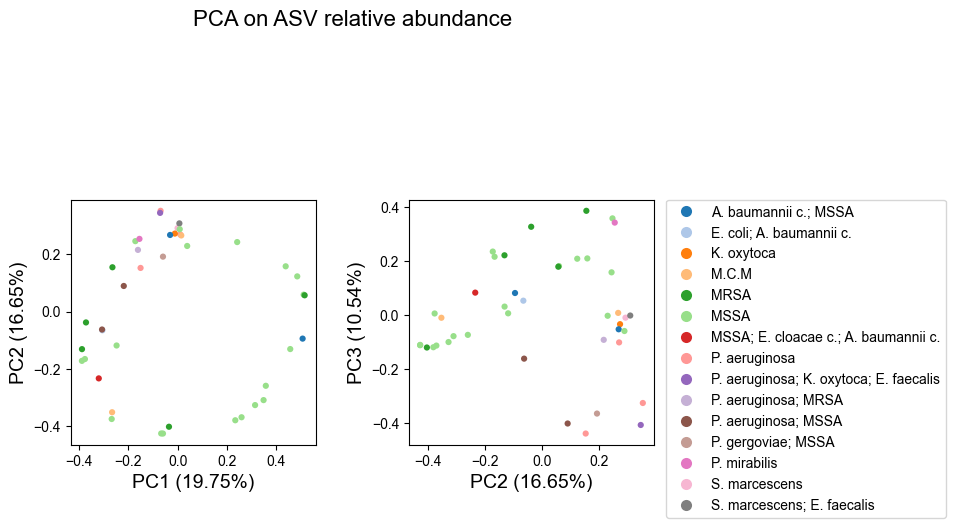

In [13]:
fig, axs = plt.subplots(1, 2, figsize=(8, 5))

plot_dm(
    # np.log10(otu_count.div(otu_count.sum(axis=1), axis=0).clip(1e-6)),
    # otu_metadata,
    # distance="euclid",
    otu_count,
    otu_metadata,
    distance="braycurtis",
    hue="result",
    hue_dict="tab20",
    s=20,
    fig=fig,
    axs=axs,
)
fig.suptitle("PCA on ASV relative abundance", fontsize=16)
fig.savefig("./figs/pcoa.svg", bbox_inches='tight')

Text(0, 0.5, 'Sequencing Depth (log scale)')

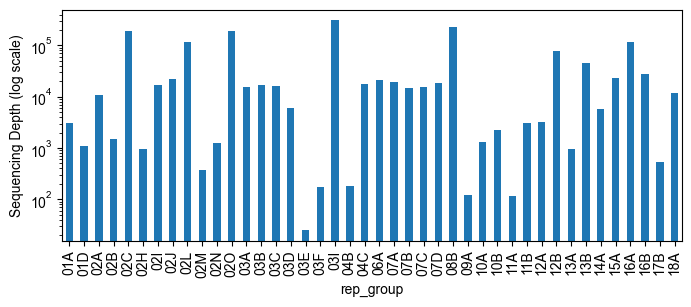

In [14]:
fig, ax = plt.subplots(figsize=(8, 3))
otu_metadata.set_index("rep_group")["sequencing_depth"].plot.bar(logy=True, ax=ax)
ax.set_ylabel("Sequencing Depth (log scale)")

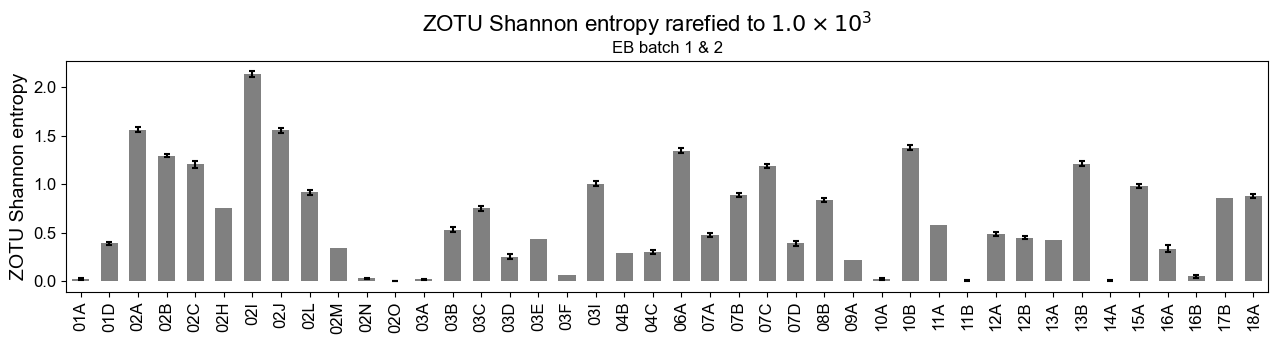

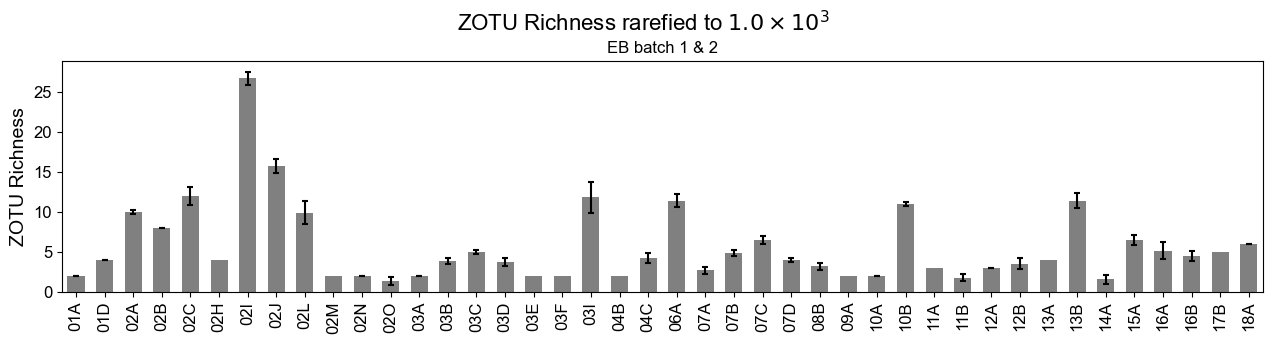

In [16]:
figs_dict = get_alpha_diversity_plot(
    otu_count,
    otu_metadata,
    otu_taxonomy,
    rep_group_key="rep_group",
    sample_group_key="sample_group",
    tax_levels=["otu"],
    rarefying_repeat=20,
    rarefying_value=1000,
    metrics=["shannon", "richness"],
)
for metric, fig_dict in figs_dict.items():
    for level, fig in fig_dict.items():
        fig.savefig(f"./figs/alpha_diversity_{metric}_{level}.svg", bbox_inches="tight")